In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load files
projects = pd.read_excel("projects_data_with_errors.xlsx")
roles = pd.read_excel("roles_data_with_errors.xlsx")
lookups = pd.ExcelFile("lookup_tables.xlsx")

print("Projects:", projects.shape)
print("Roles:", roles.shape)
print("Lookup sheets:", lookups.sheet_names)

Projects: (5939, 36)
Roles: (25050, 6)
Lookup sheets: ['countries', 'states', 'stage', 'status', 'development_type', 'contract_type', 'roles', 'categories']


In [ ]:
#Basic data checks

# See columns
print("PROJECT COLUMNS:")
print(projects.columns.tolist())

print("\nROLE COLUMNS:")
print(roles.columns.tolist())

# Row counts
print("\nROW COUNTS")
print("Projects:", len(projects))
print("Roles:", len(roles))

# Data types
print("\nPROJECT DATA TYPES")
print(projects.dtypes)

print("\nROLE DATA TYPES")
print(roles.dtypes)

# Missing values
print("\nPROJECT MISSING VALUES")
print(projects.isna().sum().sort_values(ascending=False).head(15))

print("\nROLE MISSING VALUES")
print(roles.isna().sum().sort_values(ascending=False).head(15))

PROJECT COLUMNS:
['PROJECTID', 'LASTPUBLISHED', 'PROJECT_TYPE', 'STATE', 'COUNTRYID', 'PROJECT_VALUE', 'VALUE_TYPE', 'UNITS_RESIDENTIAL', 'UNITS_INDUSTRIAL', 'UNITS_SUBDIVISIONS', 'SITE_AREA', 'FLOOR_AREA', 'AG_STOREYS', 'BG_STOREYS', 'CONSTRUCTION_START_DATE', 'CONST_START_TYPE', 'CONSTRUCTION_END_DATE', 'CONST_END_TYPE', 'STAGE_ID', 'STATUS_ID', 'STATUS_TEXT', 'VERSION', 'PA_NUMBER', 'CONSTRUCTION_CERTIFICATE_NUMBER', 'BP_NUMBER', 'OWNERSHIP_TYPE', 'CONTRACT_TYPEID', 'DEVID', 'MAIN_CONTRACTOR_APPOINTED', 'MAIN_CONTRACTOR_LISTED', 'MAIN_CONTRACTOR_APPOINTMENT_METHOD', 'MAIN_SUBCATEGORY_ID', 'LIMITED_INFO_AVAILABLE', 'NO_FURTHER_UPDATE', 'MASTER_PLAN', 'IS_AUTO_PUBLISH']

ROLE COLUMNS:
['PROJECTID', 'ROLEID', 'FIRM_NAME', 'CONTACT_NAME', 'FIRM_PHONE', 'FIRM_E_MAIL']

ROW COUNTS
Projects: 5939
Roles: 25050

PROJECT DATA TYPES
PROJECTID                                      int64
LASTPUBLISHED                         datetime64[ns]
PROJECT_TYPE                                  object
STAT

In [ ]:
# CHECK FOR DUPLICATES

print("Duplicate project IDs:", projects["PROJECTID"].duplicated().sum())

# Role duplicate check
role_cols = [c for c in ["PROJECTID", "ROLE_ID", "FIRMID"] if c in roles.columns]

if role_cols:
    print("Duplicate role assignments:", roles.duplicated(role_cols).sum())

Duplicate project IDs: 0
Duplicate role assignments: 19116


In [ ]:
# Check that every role PROJECTID exists in projects
missing_project_ids = roles.loc[
    ~roles["PROJECTID"].isin(projects["PROJECTID"]),
    "PROJECTID"
].nunique()

print("Role PROJECTIDs not found in projects:", missing_project_ids)

# Join
combined = roles.merge(
    projects,
    on="PROJECTID",
    how="left",
    suffixes=("_ROLE", "_PROJECT"),
    indicator=True
)

print("Projects rows:", len(projects))
print("Roles rows:", len(roles))
print("Joined rows:", len(combined))

print("\nJoin result:")
print(combined["_merge"].value_counts())

Role PROJECTIDs not found in projects: 0
Projects rows: 5939
Roles rows: 25050
Joined rows: 25050

Join result:
_merge
both          25050
left_only         0
right_only        0
Name: count, dtype: int64


In [ ]:
for sheet in lookups.sheet_names:
    df = pd.read_excel("lookup_tables.xlsx", sheet_name=sheet)
    print("\n", "="*50)
    print(sheet)
    print(df.shape)
    print(df.head())
    print(df.columns.tolist())


countries
(2, 2)
   country_id    reference
0          12    Australia
1          23  New Zealand
['country_id', 'reference']

states
(10, 3)
   stateorprovince_id              state  country_id
0                   1    New South Wales          12
1                   2           Victoria          12
2                   3         Queensland          12
3                   5  Western Australia          12
4                   6           Tasmania          12
['stateorprovince_id', 'state', 'country_id']

stage
(5, 2)
   projectstagesid           project_stage
0                2                 Concept
1                4  Design & Documentation
2                6        Pre-Construction
3                8            Construction
4               11             Operational
['projectstagesid', 'project_stage']

status
(35, 2)
   project_statusid                                project_status
0               111            Tender Called - Tenderers Listed\t
1               113                 

In [ ]:
def check_lookup_matches(data, lookup_file, id_columns):
    results = []

    for col in id_columns:
        if col not in data.columns:
            continue

        for sheet in lookups.sheet_names:
            lookup = pd.read_excel(lookup_file, sheet_name=sheet)

            # Check each lookup column
            for lookup_col in lookup.columns:
                values = set(lookup[lookup_col].dropna().astype(str))

                if len(values) == 0:
                    continue

                data_values = set(data[col].dropna().astype(str))

                # Only consider if there is some overlap
                overlap = len(values.intersection(data_values))

                if overlap > 0:
                    results.append({
                        "data_column": col,
                        "lookup_sheet": sheet,
                        "lookup_column": lookup_col,
                        "matches": overlap
                    })

    return pd.DataFrame(results)

In [ ]:
project_id_cols = [c for c in projects.columns if "ID" in c.upper()]
role_id_cols = [c for c in roles.columns if "ID" in c.upper()]

print("Project ID columns:", project_id_cols)
print("Role ID columns:", role_id_cols)

lookup_matches = check_lookup_matches(
    projects,
    "lookup_tables.xlsx",
    project_id_cols
)

lookup_matches

Project ID columns: ['PROJECTID', 'COUNTRYID', 'UNITS_RESIDENTIAL', 'STAGE_ID', 'STATUS_ID', 'CONTRACT_TYPEID', 'DEVID', 'MAIN_SUBCATEGORY_ID']
Role ID columns: ['PROJECTID', 'ROLEID']


,data_column,lookup_sheet,lookup_column,matches
0,COUNTRYID,countries,country_id,2
1,COUNTRYID,states,country_id,2
2,COUNTRYID,contract_type,contract_typeid,1
3,COUNTRYID,roles,roleid,2
4,COUNTRYID,categories,category_id,1
5,STAGE_ID,states,stateorprovince_id,4
6,STAGE_ID,stage,projectstagesid,5
7,STAGE_ID,development_type,devid,3
8,STAGE_ID,contract_type,contract_typeid,4
9,STAGE_ID,roles,roleid,5


In [ ]:
role_lookup_matches = check_lookup_matches(
    roles,
    "lookup_tables.xlsx",
    role_id_cols
)

role_lookup_matches

,data_column,lookup_sheet,lookup_column,matches
0,ROLEID,countries,country_id,2
1,ROLEID,states,stateorprovince_id,7
2,ROLEID,states,country_id,2
3,ROLEID,stage,projectstagesid,4
4,ROLEID,status,project_statusid,23
5,ROLEID,development_type,devid,6
6,ROLEID,contract_type,contract_typeid,7
7,ROLEID,roles,roleid,127
8,ROLEID,categories,category_id,10


In [ ]:
def unmatched_values(data, data_col, lookup_sheet, lookup_col):
    lookup = pd.read_excel(
        "lookup_tables.xlsx",
        sheet_name=lookup_sheet
    )

    valid_values = set(
        lookup[lookup_col].dropna().astype(str)
    )

    bad = data[
        data[data_col].notna() &
        ~data[data_col].astype(str).isin(valid_values)
    ]

    return bad

In [ ]:
bad_stage = unmatched_values(
    projects,
    "STAGE_ID",
    "stage",
    "projectstagesid"
)

print("Invalid stage IDs:", len(bad_stage))
bad_stage.head()

Invalid stage IDs: 0


,PROJECTID,LASTPUBLISHED,PROJECT_TYPE,STATE,COUNTRYID,PROJECT_VALUE,VALUE_TYPE,UNITS_RESIDENTIAL,UNITS_INDUSTRIAL,UNITS_SUBDIVISIONS,...,CONTRACT_TYPEID,DEVID,MAIN_CONTRACTOR_APPOINTED,MAIN_CONTRACTOR_LISTED,MAIN_CONTRACTOR_APPOINTMENT_METHOD,MAIN_SUBCATEGORY_ID,LIMITED_INFO_AVAILABLE,NO_FURTHER_UPDATE,MASTER_PLAN,IS_AUTO_PUBLISH


In [ ]:
print("Duplicate PROJECTID records:")
print(projects[projects["PROJECTID"].duplicated(keep=False)].head())

print(
    "Number of duplicate project IDs:",
    projects["PROJECTID"].duplicated().sum()
)

Duplicate PROJECTID records:
Empty DataFrame
Columns: [PROJECTID, LASTPUBLISHED, PROJECT_TYPE, STATE, COUNTRYID, PROJECT_VALUE, VALUE_TYPE, UNITS_RESIDENTIAL, UNITS_INDUSTRIAL, UNITS_SUBDIVISIONS, SITE_AREA, FLOOR_AREA, AG_STOREYS, BG_STOREYS, CONSTRUCTION_START_DATE, CONST_START_TYPE, CONSTRUCTION_END_DATE, CONST_END_TYPE, STAGE_ID, STATUS_ID, STATUS_TEXT, VERSION, PA_NUMBER, CONSTRUCTION_CERTIFICATE_NUMBER, BP_NUMBER, OWNERSHIP_TYPE, CONTRACT_TYPEID, DEVID, MAIN_CONTRACTOR_APPOINTED, MAIN_CONTRACTOR_LISTED, MAIN_CONTRACTOR_APPOINTMENT_METHOD, MAIN_SUBCATEGORY_ID, LIMITED_INFO_AVAILABLE, NO_FURTHER_UPDATE, MASTER_PLAN, IS_AUTO_PUBLISH]
Index: []

[0 rows x 36 columns]
Number of duplicate project IDs: 0


In [ ]:
role_key = ["PROJECTID", "ROLE_ID", "FIRMID"]

if all(c in roles.columns for c in role_key):
    duplicates = roles[roles.duplicated(role_key, keep=False)]

    print("Duplicate role assignments:", len(duplicates))
    display(duplicates.head(10))

In [ ]:
numeric_fields = [
    "PROJECT_VALUE",
    "SITE_AREA",
    "FLOOR_AREA",
    "UNITS_RESIDENTIAL",
    "UNITS_INDUSTRIAL",
    "UNITS_SUBDIVISIONS",
    "AG_STOREYS",
    "BG_STOREYS"
]

numeric_fields = [
    c for c in numeric_fields if c in projects.columns
]

def find_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

for col in numeric_fields:
    outliers = find_outliers(projects, col)

    print(f"{col}: {len(outliers)} outliers")
    display(outliers[["PROJECTID", col]].head(5))

PROJECT_VALUE: 958 outliers


,PROJECTID,PROJECT_VALUE
1,69884010,12984499
6,256265017,16374000
9,314368017,90000000
13,332459017,9000000
17,434939017,15500000


SITE_AREA: 630 outliers


,PROJECTID,SITE_AREA
9,314368017,2180.000
18,434948017,17.700
30,432124017,6.250
39,434950017,892.000
45,434963017,14.335


FLOOR_AREA: 282 outliers


...

,PROJECTID,UNITS_SUBDIVISIONS
64,434967017,186.0
80,434987017,230.0
109,435001017,500.0
238,435097017,183.0
333,435140017,110.0


AG_STOREYS: 275 outliers


,PROJECTID,AG_STOREYS
107,418018017,12.0
116,55385012,30.0
124,188760017,21.0
225,434929017,30.0
270,280566017,34.0


BG_STOREYS: 25 outliers


,PROJECTID,BG_STOREYS
124,188760017,4.0
443,419712017,4.0
484,391398017,4.0
780,418764017,9.0
1166,43047021,4.0


In [ ]:
print(projects["PROJECT_TYPE"].value_counts().head(30))

PROJECT_TYPE
HOUSE                                  108
HOUSES (4)                              71
HOUSE - 2 storey                        62
HOUSE - single storey                   56
HOUSES (3)                              55
WAREHOUSE                               50
TOWNHOUSES (3)                          47
TOWNHOUSES (3) - 2 storey               44
TOWNHOUSES (4) - 2 storey               42
TERRACED HOUSES (3) - single storey     39
HOUSES (4) - 2 storey                   38
HOUSES (3) - 2 storey                   37
HOUSES (5)                              35
HOUSES (2)                              30
ROAD - upgrade                          28
AGRICULTURAL BUILDING                   26
CHILDCARE CENTRE                        26
OFFICE - fitout - single level          25
TOWNHOUSES (4)                          24
TOWNHOUSES (3) - single storey          23
HOUSES (6)                              23
ROAD - rehabilitation                   22
HOUSES (5) - 2 storey                   2

In [ ]:
# Projects with residential units but project type contains infrastructure/civil keywords

keywords = "road|bridge|rail|highway|infrastructure|civil"

civil_projects = projects[
    projects["PROJECT_TYPE"]
    .astype(str)
    .str.contains(keywords, case=False, na=False)
]

bad_units = civil_projects[
    civil_projects["UNITS_RESIDENTIAL"].fillna(0) > 0
]

print("Potential civil/infrastructure + residential unit issues:",
      len(bad_units))

display(
    bad_units[
        ["PROJECTID", "PROJECT_TYPE", "UNITS_RESIDENTIAL"]
    ].head(10)
)

Potential civil/infrastructure + residential unit issues: 7


,PROJECTID,PROJECT_TYPE,UNITS_RESIDENTIAL
2236,436260017,PEDESTRIAN CROSSING for ROAD - upgrade,8.0
2503,432227017,"BASEMENT CAR PARK (1,060 spaces) | LOADING DOC...",1.0
2698,404197017,CULVERTS & KERBS for ROAD - supply & install,16.0
3695,434750017,BRIDGE - maintenance,45.0
4334,437597017,CIVIL INFRASTRUCTURE WORKS for KEY WORKER / AF...,47.0
5216,389930017,HOUSING ESTATE | INFRASTRUCTURE,1.0
5260,437321017,TRUNK ROAD | WATER & SEWER INFRASTRUCTURE for ...,1.0


In [ ]:
for col in numeric_fields:
    bad = projects[projects[col] < 0]

    if len(bad) > 0:
        print(f"\n{col}: {len(bad)} negative values")
        display(bad[["PROJECTID", col]].head())

In [ ]:
for col in ["SITE_AREA", "FLOOR_AREA", "AG_STOREYS", "BG_STOREYS"]:
    if col in projects.columns:
        bad = projects[projects[col] <= 0]

        print(col, "non-positive values:", len(bad))

SITE_AREA non-positive values: 40
FLOOR_AREA non-positive values: 98
AG_STOREYS non-positive values: 185
BG_STOREYS non-positive values: 1


In [ ]:
summary = pd.DataFrame({
    "Mean": projects[numeric_fields].mean(),
    "Median": projects[numeric_fields].median()
})

summary["Mean / Median"] = (
    summary["Mean"] / summary["Median"]
)

summary

,Mean,Median,Mean / Median
PROJECT_VALUE,2.878433e+07,1250000.00,23.027461
SITE_AREA,2.169063e+03,0.23,9430.710314
FLOOR_AREA,9.044998e+03,621.00,14.565214
UNITS_RESIDENTIAL,3.732792e+01,4.00,9.331980
UNITS_INDUSTRIAL,5.321591e+00,1.00,5.321591
UNITS_SUBDIVISIONS,7.047368e+01,11.00,6.406699
AG_STOREYS,3.653044e+00,2.00,1.826522
BG_STOREYS,1.902439e+00,1.00,1.902439


In [ ]:
for col in numeric_fields:
    mean = projects[col].mean()
    median = projects[col].median()

    print(
        f"{col}: Mean={mean:,.2f}, "
        f"Median={median:,.2f}"
    )

PROJECT_VALUE: Mean=28,784,326.25, Median=1,250,000.00
SITE_AREA: Mean=2,169.06, Median=0.23
FLOOR_AREA: Mean=9,045.00, Median=621.00
UNITS_RESIDENTIAL: Mean=37.33, Median=4.00
UNITS_INDUSTRIAL: Mean=5.32, Median=1.00
UNITS_SUBDIVISIONS: Mean=70.47, Median=11.00
AG_STOREYS: Mean=3.65, Median=2.00
BG_STOREYS: Mean=1.90, Median=1.00


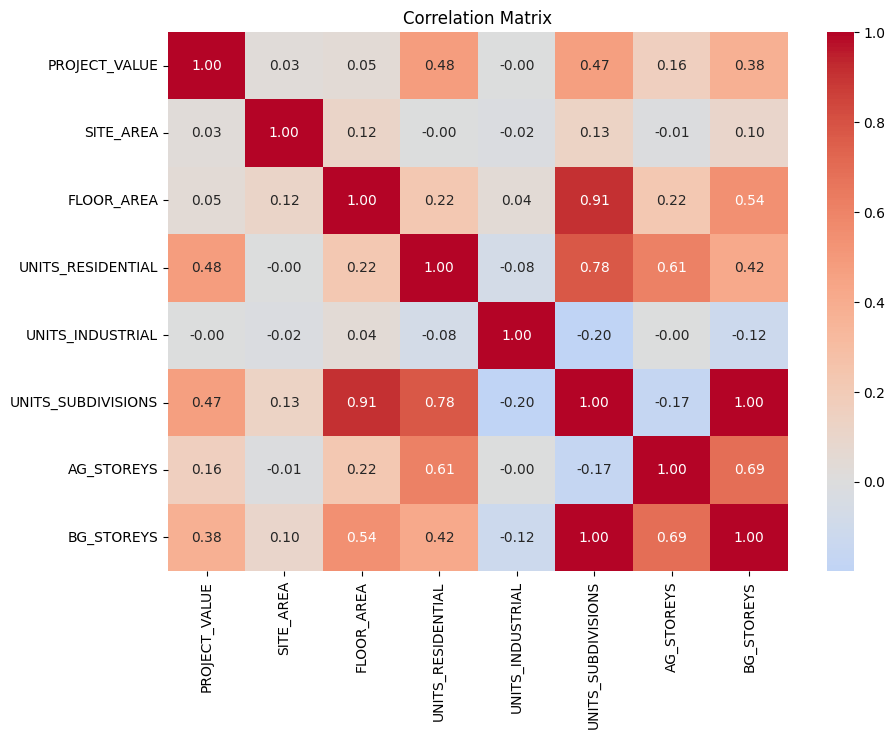

In [ ]:
corr = projects[numeric_fields].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        pairs.append({
            "Variable 1": corr.columns[i],
            "Variable 2": corr.columns[j],
            "Correlation": corr.iloc[i, j]
        })

pairs = pd.DataFrame(pairs)

print("Strongest positive correlations:")
display(
    pairs.sort_values("Correlation", ascending=False).head(5)
)

print("Strongest negative correlations:")
display(
    pairs.sort_values("Correlation").head(5)
)

Strongest positive correlations:


,Variable 1,Variable 2,Correlation
26,UNITS_SUBDIVISIONS,BG_STOREYS,1.000000
15,FLOOR_AREA,UNITS_SUBDIVISIONS,0.907115
19,UNITS_RESIDENTIAL,UNITS_SUBDIVISIONS,0.777246
27,AG_STOREYS,BG_STOREYS,0.687287
20,UNITS_RESIDENTIAL,AG_STOREYS,0.614501


Strongest negative correlations:


,Variable 1,Variable 2,Correlation
22,UNITS_INDUSTRIAL,UNITS_SUBDIVISIONS,-0.198816
25,UNITS_SUBDIVISIONS,AG_STOREYS,-0.166935
24,UNITS_INDUSTRIAL,BG_STOREYS,-0.116592
18,UNITS_RESIDENTIAL,UNITS_INDUSTRIAL,-0.075787
9,SITE_AREA,UNITS_INDUSTRIAL,-0.016473


In [ ]:
# Calculate number of populated fields per project
projects["POPULATED_FIELDS"] = projects.notna().sum(axis=1)

# Remove our helper column from the calculation
original_project_cols = [
    c for c in projects.columns
    if c != "POPULATED_FIELDS"
]

projects["POPULATED_FIELDS"] = projects[
    original_project_cols
].notna().sum(axis=1)

completeness = (
    projects.groupby("STATE")["POPULATED_FIELDS"]
    .mean()
    .sort_values(ascending=False)
)

completeness

,POPULATED_FIELDS
STATE,
8,25.571429
100,25.251682
4,25.170732
3,24.681159
1,24.431000
2,24.269451
6,23.985915
5,23.808511
7,23.204545


In [ ]:
role_state = roles.merge(
    projects[["PROJECTID", "STATE"]],
    on="PROJECTID",
    how="left"
)

cols = ["CONTACT_NAME", "FIRM_PHONE", "FIRM_E_MAIL"]

for c in cols:
    role_state[c] = role_state[c].astype(str).str.lower().eq("available")

disclosure = role_state.groupby("STATE")[cols].mean() * 100
disclosure["Overall"] = disclosure.mean(axis=1)

disclosure.index.name = "STATE"
display(disclosure.round(1))
print("Highest disclosure:", disclosure["Overall"].idxmax())

,CONTACT_NAME,FIRM_PHONE,FIRM_E_MAIL,Overall
STATE,,,,
1,50.7,97.9,94.5,81.0
2,35.2,97.7,93.6,75.5
3,50.3,98.5,92.9,80.6
4,49.8,97.3,91.2,79.5
5,31.2,98.2,87.7,72.4
6,43.5,99.2,96.2,79.6
7,34.3,99.0,85.6,73.0
8,62.8,97.4,92.1,84.1
100,33.2,87.0,77.2,65.8


Highest disclosure: 8


In [ ]:
# Load the roles lookup table to get descriptive role names
roles_lookup = pd.read_excel(
    "lookup_tables.xlsx",
    sheet_name="roles"
)

# Merge combined DataFrame with roles_lookup to get ROLE_TEXT
combined_with_role_text = combined.merge(
    roles_lookup,
    left_on="ROLEID",
    right_on="roleid",
    how="left"
).rename(columns={"roles": "ROLE_TEXT"})

# Filter the data based on the desired ROLE_TEXT values
target = combined_with_role_text[
    combined_with_role_text["ROLE_TEXT"].isin(
        ["Architect", "Developer", "Builder / Main Contractor"]
    )
]

# Create a cross-tabulation of ROLE_TEXT by STAGE_ID
result = pd.crosstab(
    target["ROLE_TEXT"],
    target["STAGE_ID"]
)

display(result)

STAGE_ID,2,4,6,8,11
ROLE_TEXT,,,,,
Architect,33,778,258,252,0
Builder / Main Contractor,4,391,1027,430,1
Developer,736,1866,1780,527,19


In [ ]:
display(
    pd.crosstab(
        target["ROLE_TEXT"],
        target["STAGE_ID"],
        normalize="index"
    ).round(2) * 100
)

STAGE_ID,2,4,6,8,11
ROLE_TEXT,,,,,
Architect,2.0,59.0,20.0,19.0,0.0
Builder / Main Contractor,0.0,21.0,55.0,23.0,0.0
Developer,15.0,38.0,36.0,11.0,0.0


In [ ]:
category = pd.read_excel(
    "lookup_tables.xlsx",
    sheet_name="categories"
)

display(category)

,category_id,reference
0,2,Education
1,3,Health
2,4,Hospitality
3,5,Industrial
4,6,Infrastructure
...,...,...
116,3021,Oil & Gas Drilling
117,3022,Oil & Gas Exploration
118,3023,Residential Estate
119,3025,Subdivision


In [ ]:
target_projects = projects[
    projects["MAIN_SUBCATEGORY_ID"] == 2 # Using 2 as an example for 'Education'. Replace with your desired category ID.
]

target_roles = roles[
    roles["PROJECTID"].isin(target_projects["PROJECTID"])
]

# Merge target_roles with roles_lookup to get ROLE_TEXT
target_roles = target_roles.merge(
    roles_lookup,
    left_on="ROLEID",
    right_on="roleid",
    how="left"
).rename(columns={"roles": "ROLE_TEXT"})


display(
    target_roles["ROLEID"]
    .value_counts()
    .head(5)
)

,count
ROLEID,


In [ ]:
display(
    target_roles["ROLE_TEXT"]
    .value_counts()
    .head(5)
)

,count
ROLE_TEXT,


In [ ]:
for c in projects.columns:
    if "DATE" in c.upper():
        projects[c] = pd.to_datetime(projects[c], errors="coerce")

In [ ]:
bad_dates = projects[
    projects["CONSTRUCTION_END_DATE"] < projects["CONSTRUCTION_START_DATE"]
]

print("Invalid date records:", len(bad_dates))
display(bad_dates.head())

Invalid date records: 0


,PROJECTID,LASTPUBLISHED,PROJECT_TYPE,STATE,COUNTRYID,PROJECT_VALUE,VALUE_TYPE,UNITS_RESIDENTIAL,UNITS_INDUSTRIAL,UNITS_SUBDIVISIONS,...,DEVID,MAIN_CONTRACTOR_APPOINTED,MAIN_CONTRACTOR_LISTED,MAIN_CONTRACTOR_APPOINTMENT_METHOD,MAIN_SUBCATEGORY_ID,LIMITED_INFO_AVAILABLE,NO_FURTHER_UPDATE,MASTER_PLAN,IS_AUTO_PUBLISH,POPULATED_FIELDS


In [ ]:
display(
    projects[numeric_fields].agg(["mean", "median"]).round(2)
)

,PROJECT_VALUE,SITE_AREA,FLOOR_AREA,UNITS_RESIDENTIAL,UNITS_INDUSTRIAL,UNITS_SUBDIVISIONS,AG_STOREYS,BG_STOREYS
mean,28784326.25,2169.06,9045.0,37.33,5.32,70.47,3.65,1.9
median,1250000.00,0.23,621.0,4.00,1.00,11.00,2.00,1.0


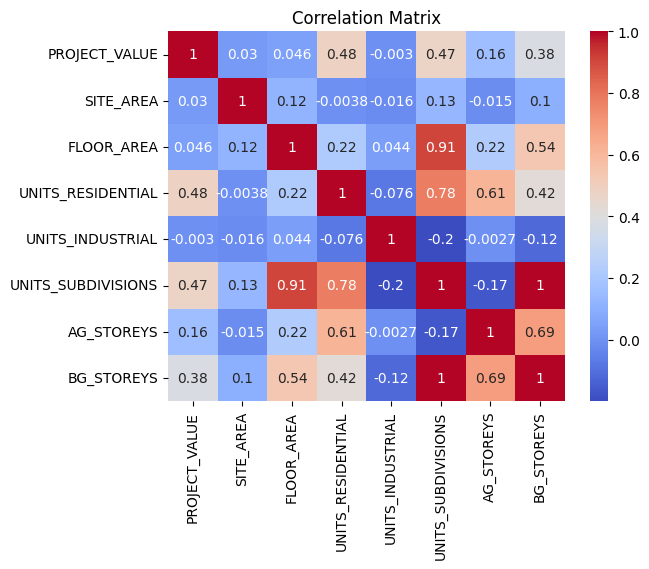

In [ ]:
corr = projects[numeric_fields].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()